In [ ]:
# ==========================================
# STEP 1 : IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Train-test split
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
# ==========================================
# STEP 2 : LOAD DATASET
# ==========================================

df = pd.read_csv("/content/student-scores.csv")

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [ ]:
# ==========================================
# STEP 3 : EXPLORE DATASET
# ==========================================

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(2000, 17)

Column Names:
Index(['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job',
       'absence_days', 'extracurricular_activities', 'weekly_self_study_hours',
       'career_aspiration', 'math_score', 'history_score', 'physics_score',
       'chemistry_score', 'biology_score', 'english_score', 'geography_score'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   absence_days                2000 non-nul

In [ ]:
# ==========================================
# STEP 4 : CHECK MISSING VALUES
# ==========================================

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64


In [ ]:
# ==========================================
# STEP 5 : SELECT REQUIRED COLUMNS
# ==========================================

df = df[[ "weekly_self_study_hours", "math_score"]]

print(df.head())

   weekly_self_study_hours  math_score
0                       27          73
1                       47          90
2                       13          81
3                        3          71
4                       10          84


In [ ]:
# ==========================================
# STEP 6 : HANDLE MISSING VALUES
# ==========================================

print("Missing values before:")
print(df.isnull().sum())

df = df.dropna()

print("\nMissing values after:")
print(df.isnull().sum())

Missing values before:
weekly_self_study_hours    0
math_score                 0
dtype: int64

Missing values after:
weekly_self_study_hours    0
math_score                 0
dtype: int64


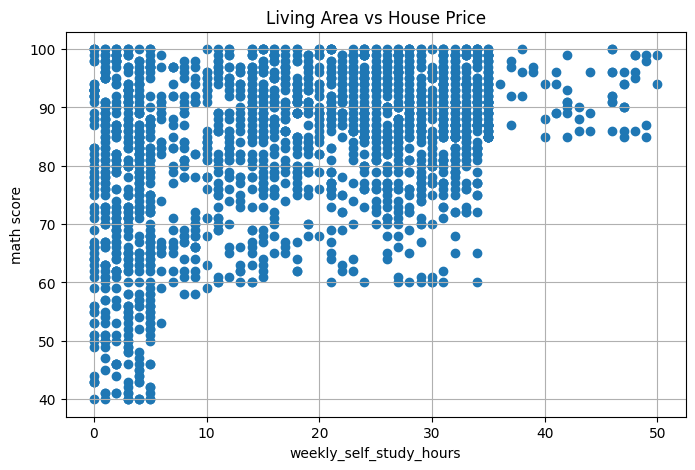

In [ ]:
# ==========================================
# STEP 7 : VISUALIZE ORIGINAL DATA
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["weekly_self_study_hours"],
    df["math_score"]

)

plt.xlabel("weekly_self_study_hours")
plt.ylabel("math score")
plt.title("Living Area vs House Price")

plt.grid(True)

plt.show()

In [ ]:
# Input feature
X = df[["weekly_self_study_hours"]]

# Output / target
y = df[["math_score"]]


print("Input X:")
print(X.head())

print("\nTarget y:")
print(y.head())

Input X:
   weekly_self_study_hours
0                       27
1                       47
2                       13
3                        3
4                       10

Target y:
   math_score
0          73
1          90
2          81
3          71
4          84


In [ ]:
# ==========================================
# STEP 9 : TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

Training data shape: (1600, 1)
Testing data shape : (400, 1)


In [12]:
# ==========================================
# STEP 10 : CONVERT TO PYTORCH TENSORS
# ==========================================

X_train = torch.tensor(
    X_train.values,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test.values,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: torch.Size([1600, 1])
X_test shape : torch.Size([400, 1])
y_train shape: torch.Size([1600, 1])
y_test shape : torch.Size([400, 1])


In [13]:
# ==========================================
# STEP 11 : BUILD LINEAR REGRESSION MODEL
# ==========================================

class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        # 1 input feature and 1 output
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)


model = LinearRegressionModel()

print(model)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [14]:
# ==========================================
# STEP 12 : DEFINE LOSS FUNCTION
# ==========================================

criterion = nn.MSELoss()

print("Loss Function:")
print(criterion)

Loss Function:
MSELoss()


In [15]:
# ==========================================
# STEP 13 : DEFINE ADAM OPTIMIZER
# ==========================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.000001
)

print("Optimizer:")
print(optimizer)

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-06
    maximize: False
    weight_decay: 0
)


In [16]:
# ==========================================
# STEP 14 : TRAIN THE MODEL
# ==========================================

epochs = 2000

loss_history = []

for epoch in range(epochs):

    # Forward pass
    predictions = model(X_train)

    # Calculate loss
    loss = criterion(predictions, y_train)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weight and bias
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    # Display loss
    if (epoch + 1) % 200 == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [200/2000], Loss: 4728.1074
Epoch [400/2000], Loss: 4727.6211
Epoch [600/2000], Loss: 4727.1348
Epoch [800/2000], Loss: 4726.6489
Epoch [1000/2000], Loss: 4726.1631
Epoch [1200/2000], Loss: 4725.6777
Epoch [1400/2000], Loss: 4725.1914
Epoch [1600/2000], Loss: 4724.7051
Epoch [1800/2000], Loss: 4724.2197
Epoch [2000/2000], Loss: 4723.7339


In [17]:
# ==========================================
# STEP 15 : DISPLAY LEARNED PARAMETERS
# ==========================================

weight = model.linear.weight.item()
bias = model.linear.bias.item()

print("Learned Weight:", weight)
print("Learned Bias  :", bias)

Learned Weight: 0.9292294979095459
Learned Bias  : -0.5994757413864136


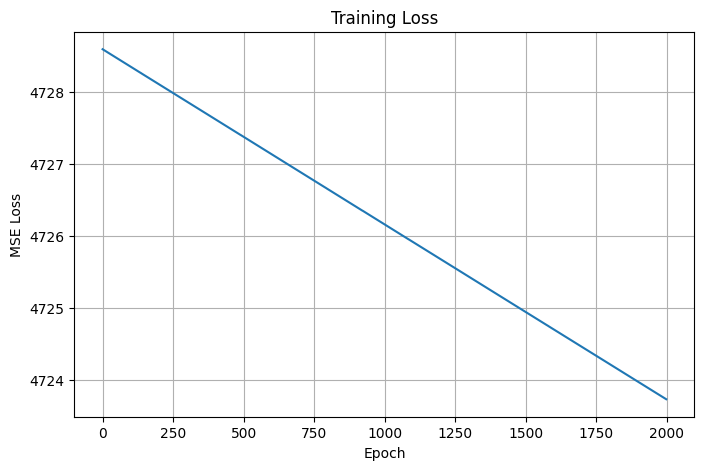

In [18]:
# ==========================================
# STEP 16 : PLOT TRAINING LOSS
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

In [19]:
# ==========================================
# STEP 17 : MAKE PREDICTIONS
# ==========================================

model.eval()

with torch.no_grad():

    y_pred = model(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
tensor([[17.0559],
        [ 0.3298],
        [14.2682],
        [ 4.0467],
        [ 1.2590],
        [ 4.0467],
        [13.3390],
        [29.1359],
        [ 1.2590],
        [ 3.1174]])


In [20]:
# ==========================================
# STEP 18 : COMPARE ACTUAL AND PREDICTED
# ==========================================

print("Actual Price       Predicted Price")

for actual, predicted in zip(y_test[:10], y_pred[:10]):

    print(
        f"{actual.item():.2f}"
        f"          "
        f"{predicted.item():.2f}"
    )

Actual Price       Predicted Price
97.00          17.06
85.00          0.33
80.00          14.27
57.00          4.05
86.00          1.26
99.00          4.05
98.00          13.34
87.00          29.14
90.00          1.26
92.00          3.12


In [21]:
# ==========================================
# STEP 19 : EVALUATE THE MODEL
# ==========================================

# Convert tensors to NumPy arrays
y_test_numpy = y_test.numpy()
y_pred_numpy = y_pred.numpy()

# Mean Squared Error
mse = mean_squared_error(
    y_test_numpy,
    y_pred_numpy
)

# Mean Absolute Error
mae = mean_absolute_error(
    y_test_numpy,
    y_pred_numpy
)

# R2 Score
r2 = r2_score(
    y_test_numpy,
    y_pred_numpy
)

print("MODEL EVALUATION")
print("----------------------------")

print("Mean Squared Error :", mse)
print("Mean Absolute Error:", mae)
print("R2 Score           :", r2)

MODEL EVALUATION
----------------------------
Mean Squared Error : 4844.37548828125
Mean Absolute Error: 68.31791687011719
R2 Score           : -28.192623138427734


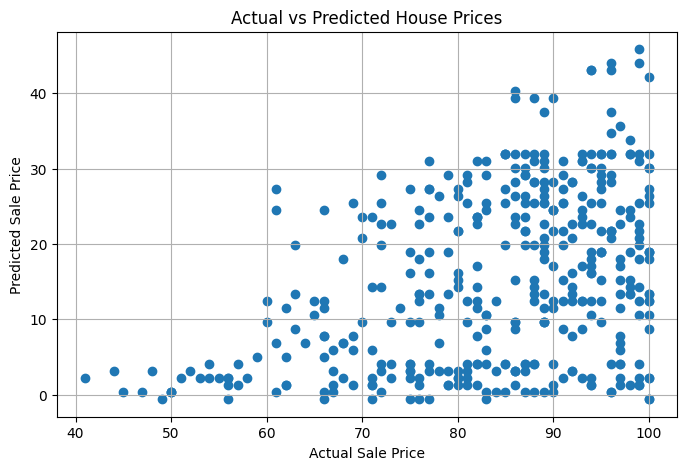

In [22]:
# ==========================================
# STEP 20 : ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_numpy,
    y_pred_numpy
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

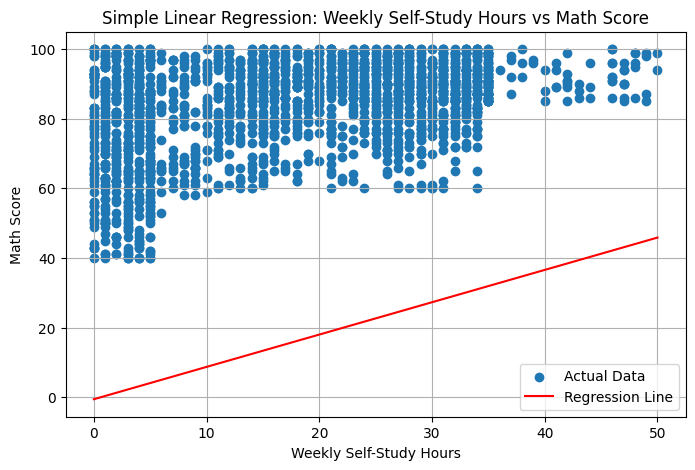

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Import pandas to load and process data
from pathlib import Path # Import Path for file existence check

# ==========================================
# STEP 21 : PLOT REGRESSION LINE
# ==========================================

# Re-define necessary variables for plotting.
# This cell is made self-contained to run independently if previous cells haven't been executed
# or if the kernel state has been reset.

file_path = "/content/student-scores.csv"

try:
    # Attempt to load the full dataset
    df_full = pd.read_csv(file_path)

    # Select the required columns for 'df' as done in cell 'aj4qnX0u1y0A'
    df_selected = df_full[[ "weekly_self_study_hours", "math_score"]]

    # Define X and y DataFrames as done in cell 'DMRNVeFU1xxT'
    X = df_selected[["weekly_self_study_hours"]]
    y = df_selected[["math_score"]]

    # Hardcode learned weight and bias from previous training results (cell 'uLfCdw534JGM')
    # These values were: Learned Weight: 0.9292294979095459, Learned Bias: -0.5994757413864136
    weight = 0.9292294979095459
    bias = -0.5994757413864136

    plt.figure(figsize=(8, 5))

    # Actual data points
    # Use the X and y DataFrames which represent the input and target features before tensor conversion
    plt.scatter(
        X["weekly_self_study_hours"], # Use the 'weekly_self_study_hours' column from DataFrame X
        y["math_score"],              # Use the 'math_score' column from DataFrame y
        label="Actual Data"
    )

    # Generate x values for the regression line
    # Use the min and max from the 'weekly_self_study_hours' column of DataFrame X
    x_line = np.linspace(
        X["weekly_self_study_hours"].min(),
        X["weekly_self_study_hours"].max(),
        100
    )

    # Calculate predicted y values using the learned weight and bias
    y_line = weight * x_line + bias

    # Plot the Regression line
    plt.plot(
        x_line,
        y_line,
        color='red',
        label="Regression Line"
    )

    plt.xlabel("Weekly Self-Study Hours")
    plt.ylabel("Math Score")

    plt.title("Simple Linear Regression: Weekly Self-Study Hours vs Math Score")

    plt.legend()

    plt.grid(True)

    plt.show()

except FileNotFoundError:
    print(f"ERROR: The file '{file_path}' was not found.")
    print("Please ensure the 'student-scores.csv' file is uploaded to the Colab environment.")
    print("You can upload it by clicking the folder icon on the left sidebar, then the 'Upload to session storage' icon.")
    print("Alternatively, if you have a public URL for the file, you can add a `!wget` command before `pd.read_csv`.")